In [1]:
import numpy as np
import pandas as pd
from obspy import UTCDateTime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter, MultipleLocator

import seaborn as sns
from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import scipy.stats as stats
from scipy.odr import ODR, Model, RealData

from tqdm import tqdm

import sys
sys.path.append('../')
from functions.data_processing.read_data import load_label
from functions.utils import *

# Volume Relation with Impact Force

In [2]:
import json
with open("../config/event_id_map.json", "r") as f:
    event_id_map = json.load(f)

In [3]:
volume_df = pd.read_csv("../label/DF_Characteristics_2019-2023.csv", index_col=0)
volume_df.drop(1, inplace=True)
volume_df.reset_index(drop=True, inplace=True)
volume_df['Event_Date'] = volume_df['Event_Date'].apply(lambda x: UTCDateTime(x))
volume_df.dropna(axis=0, subset=['Volume'], inplace=True)
volume_df.tail()


,Event_Date,Year,Julday,Volume,Velocity,Duration,Density
36,2023-06-02T00:00:00.000000Z,2023,153,4873.0,1.73,NaN,1724
37,2023-06-10T00:00:00.000000Z,2023,161,18534.0,2.02,NaN,1787
38,2023-07-12T00:00:00.000000Z,2023,193,119088.0,15.46,NaN,1785
39,2023-07-13T00:00:00.000000Z,2023,194,301099.0,10.70,NaN,1342
40,2023-11-14T00:00:00.000000Z,2023,318,103808.0,8.28,NaN,1514


In [4]:
vol_err_percent = 0.5

volume_df_2019 = volume_df[volume_df['Year'] == 2019]
volume_df_2019['Event_ID'] = [1, 3, 4, 5, 6, 7, 8, 9]
volume_df_2019 = volume_df_2019[volume_df_2019['Event_ID'] != 5]
volume_2019 = volume_df_2019['Volume'].to_numpy()
volume_2019_l = volume_2019 * vol_err_percent
volume_2019_u = volume_2019 * vol_err_percent
volume_bounds_2019 = np.column_stack((volume_2019_l, volume_2019_u))
density_2019 = volume_df_2019['Density'].to_numpy()
print(volume_2019, density_2019)

volume_df_2020 = volume_df[volume_df['Year'] == 2020]
volume_2020 = []
density_2020 = []
for idx, row in volume_df_2020.iterrows():
    if row['Julday'] in [156, 160, 169, 181, 243]:
        volume_2020.append(row['Volume'])
        density_2020.append(row['Density'])

print(volume_2020, density_2020)
volume_2020 = np.array(volume_2020)
volume_2020_l = volume_2020 * vol_err_percent
volume_2020_u = volume_2020 * vol_err_percent
volume_bounds_2020 = np.column_stack((volume_2020_l, volume_2020_u))

volume_df_2021 = volume_df[volume_df['Year'] == 2021]
volume_2021 = []
density_2021 = []
for idx, row in volume_df_2021.iterrows():
    if row['Julday'] in [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]:
        volume_2021.append(row['Volume'])
        density_2021.append(row['Density'])
print(volume_2021, density_2021)
volume_2021 = np.array(volume_2021)
volume_2021_l = volume_2021 * vol_err_percent
volume_2021_u = volume_2021 * vol_err_percent
volume_bounds_2021 = np.column_stack((volume_2021_l, volume_2021_u))

volume_df_2022 = volume_df[volume_df['Year'] == 2022]
volume_2022 = []
density_2022 = []
for idx, row in volume_df_2022.iterrows():
    if row['Julday'] in [156, 185]:
        volume_2022.append(row['Volume'])
        density_2022.append(row['Density'])
print(volume_2022, density_2022)
volume_2022 = np.array(volume_2022)
volume_2022_l = volume_2022 * vol_err_percent
volume_2022_u = volume_2022 * vol_err_percent
volume_bounds_2022 = np.column_stack((volume_2022_l, volume_2022_u))

volume_df_2023 = volume_df[volume_df['Year'] == 2023]
volume_2023 = []
density_2023 = []
for idx, row in volume_df_2023.iterrows():
    if row['Julday'] in [153, 161, 193]:
        volume_2023.append(row['Volume'])
        density_2023.append(row['Density'])
print(volume_2023, density_2023)
volume_2023 = np.array(volume_2023)
volume_2023_l = volume_2023 * vol_err_percent
volume_2023_u = volume_2023 * vol_err_percent
volume_bounds_2023 = np.column_stack((volume_2023_l, volume_2023_u))

[ 2313. 83123. 73144.  9869. 29077. 70705. 21031.] [1682 1870 1827 2191 2223 2323 2031]
[92424.0, 5872.0, 5053.0, 6612.0, 95823.0] [1773, 1495, 1862, 2066, 1777]
[17741.0, 18972.0, 18044.0, 6127.0, 6175.0, 114424.0, 76906.0, 50861.0, 80880.0, 38737.0, 8538.0] [1675, 1455, 1669, 1602, 1749, 1628, 1605, 1373, 1916, 1884, 1697]
[39498.0, 115963.0] [1690, 1140]
[4873.0, 18534.0, 119088.0] [1724, 1787, 1785]


/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_16135/1741606007.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volume_df_2019['Event_ID'] = [1, 3, 4, 5, 6, 7, 8, 9]


Text(0, 0.5, 'Volume (m³)')

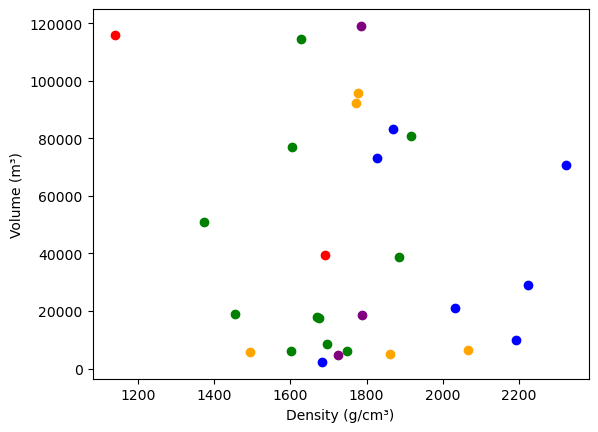

In [5]:
plt.scatter(density_2019, volume_2019, label='2019', color='blue')
plt.scatter(density_2020, volume_2020, label='2020', color='orange')
plt.scatter(density_2021, volume_2021, label='2021', color='green')
plt.scatter(density_2022, volume_2022, label='2022', color='red')
plt.scatter(density_2023, volume_2023, label='2023', color='purple')
plt.xlabel('Density (g/cm³)')
plt.ylabel('Volume (m³)')

In [6]:
interval_seconds = 15
thres = 2

In [7]:
volume_2019 = []
csum_list = []
csum_list_l = []
csum_list_u = []
julday_list_2019 = []
for idx, row in tqdm(volume_df_2019.iterrows(), total=len(volume_df_2019)):
    if row['Event_ID'] == 5:
        continue
    event_info = event_id_map[str(row['Event_ID'])]
    label = load_label([str(row['Event_ID'])], "ILL11", interval_seconds, "average", True, 0, divide_by=None)
    label = label[label['Fv [kN]'] > thres]
    csum = label['Fv [kN]'].sum()
    csum_list.append(np.round(csum))
    csum_l = label['Fv min'].sum()
    csum_list_l.append(np.round(csum_l))
    csum_u = label['Fv max'].sum()
    csum_list_u.append(np.round(csum_u))
    volume_2019.append(row['Volume'])
    julday_list_2019.append(f"{row['Julday']}-{str(row['Year'])[-2:]}")

csum_list = np.array(csum_list)
csum_list_l = np.array(csum_list_l)
csum_list_u = np.array(csum_list_u)
csum_bounds = np.column_stack((csum_list - csum_list_l, csum_list_u - csum_list))

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:24<00:00,  3.51s/it]


In [9]:
test_dir = "../comparison_baseline_cv_5_30_4/average_60_45/model_test"
test_dir

'../comparison_baseline_cv_5_30_4/average_60_45/model_test'

In [10]:
interval = interval_seconds
year = 2019
juldays = [161, 172, 182, 196, 207, 223, 232]
event_ids = ["1", "3", "4", "6", "7", "8", "9"]
results_2019 = {}
julday_list_2019 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
for model in ['xLSTM']:
    prediction_csums = []
    i = 0
    for julday, event_id in tqdm(zip(juldays, event_ids), total=len(juldays)):
        if julday in [182, 183]:
            df1 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
            df2 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday+1}.csv", index_col=False)
            df = pd.concat([df1, df2], ignore_index=True)
        else:
            df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(event_id_map[event_id]['start_time']), UTCDateTime(event_id_map[event_id]['end_time']))]
        df.reset_index(drop=True, inplace=True)
        label = load_label([event_id], "ILL11", interval_seconds, "average", True, 60, divide_by=None)
        label['Timestamp'] = label['Timestamp'].apply(lambda x: UTCDateTime(x))
        combined = df.merge(label, how='left', left_on='Timestamps', right_on='Timestamp')
        combined.drop(columns=['Timestamp'], inplace=True)
        temp = combined[combined['Fv [kN]'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum(), 
                                 (temp['Predicted_Output_Mean'] - temp['Predicted_Output_Min']).sum(),
                                 (temp['Predicted_Output_Max'] - temp['Predicted_Output_Mean']).sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2019[model] = prediction_csums

100%|██████████| 7/7 [00:32<00:00,  4.59s/it]


In [11]:
interval = interval_seconds
year = 2020
juldays = [156, 160, 169, 181, 243]
start_times = ["2020-06-04 15:00:00", "2020-06-08 15:00:00", "2020-06-17 03:00:00", "2020-06-29 04:30:00", "2020-08-30 05:00:00"] # "2020-06-07 09:00:00"
end_times = ["2020-06-04 18:00:00", "2020-06-08 21:00:00", "2020-06-17 07:00:00", "2020-06-29 07:30:00", "2020-08-30 12:00:00"] # "2020-06-07 10:30:00"
julday_list_2020 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2020 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum(), 
                                 (temp['Predicted_Output_Mean'] - temp['Predicted_Output_Min']).sum(),
                                 (temp['Predicted_Output_Max'] - temp['Predicted_Output_Mean']).sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2020[model] = prediction_csums

100%|██████████| 5/5 [00:01<00:00,  4.98it/s]


In [12]:
interval = interval_seconds
year = 2021
juldays = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:00:00", "2021-06-05 09:00:00",
            "2021-06-22 19:00:00", "2021-06-24 14:30:00", "2021-07-06 18:00:00", "2021-07-13 15:00:00",
            "2021-07-16 03:00:00", "2021-08-07 13:30:00", "2021-09-19 05:30:00"]
end_times = ["2021-05-11 19:30:00", "2021-05-16 22:00:00", "2021-05-22 02:30:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 19:00:00", "2021-07-06 22:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 18:00:00", "2021-09-19 12:30:00"]
julday_list_2021 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2021 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        if julday == 142:
            df1 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday-1}.csv", index_col=False)
            df2 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
            df = pd.concat([df1, df2], ignore_index=True)
        else:
            df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum(), 
                                 (temp['Predicted_Output_Mean'] - temp['Predicted_Output_Min']).sum(),
                                 (temp['Predicted_Output_Max'] - temp['Predicted_Output_Mean']).sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2021[model] = prediction_csums

100%|██████████| 11/11 [00:02<00:00,  5.18it/s]


In [13]:
interval = interval_seconds
year = 2022
juldays = [156, 185]
start_times = ["2022-06-05 10:30:00", "2022-07-04 21:00:00"]
end_times = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]
julday_list_2022 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2022 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum(), 
                                 (temp['Predicted_Output_Mean'] - temp['Predicted_Output_Min']).sum(),
                                 (temp['Predicted_Output_Max'] - temp['Predicted_Output_Mean']).sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2022[model] = prediction_csums

100%|██████████| 2/2 [00:00<00:00,  5.43it/s]


In [14]:
interval = interval_seconds
year = 2023
juldays = [153, 161, 193]
start_times = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:00:00"]
end_times = ["2023-06-02 21:30:00", "2023-06-10 09:30:00", "2023-07-12 06:00:00"]
julday_list_2023 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2023 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum(), 
                                 (temp['Predicted_Output_Mean'] - temp['Predicted_Output_Min']).sum(),
                                 (temp['Predicted_Output_Max'] - temp['Predicted_Output_Mean']).sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2023[model] = prediction_csums

100%|██████████| 3/3 [00:00<00:00,  4.83it/s]


In [17]:
volume_dict = {}
for jul, vol in zip(julday_list_2019, volume_2019):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2020, volume_2020):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2021, volume_2021):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2022, volume_2022):
    volume_dict[jul] = int(vol)
for jul, vol in zip(julday_list_2023, volume_2023):
    volume_dict[jul] = int(vol)

In [18]:
volume_dict

{'161-19': 2313,
 '172-19': 83123,
 '182-19': 73144,
 '196-19': 9869,
 '207-19': 29077,
 '223-19': 70705,
 '232-19': 21031,
 '156-20': 92424,
 '160-20': 5872,
 '169-20': 5053,
 '181-20': 6612,
 '243-20': 95823,
 '131-21': 17741,
 '136-21': 18972,
 '142-21': 18044,
 '156-21': 6127,
 '173-21': 6175,
 '175-21': 114424,
 '187-21': 76906,
 '194-21': 50861,
 '197-21': 80880,
 '219-21': 38737,
 '262-21': 8538,
 '156-22': 39498,
 '185-22': 115963,
 '153-23': 4873,
 '161-23': 18534,
 '193-23': 119088}

In [ ]:
df1 = pd.read_csv("erosion.csv")
df1['Julday'] = df1['Date'].apply(lambda x: UTCDateTime(x).julday)
df1['Year'] = df1['Date'].apply(lambda x: UTCDateTime(x).year)
df1 = df1.drop([6, 14])
df1.reset_index(drop=True, inplace=True)
df1.head()

,Date,Erosion1,Erosion2,Erosion3,CFS,Julday,Year
0,2019-06-21,-5.8157,-1.7500,NaN,3227.68,172,2019
1,2019-07-15,4.6391,0.3300,NaN,860.40,196,2019
2,2019-07-26,-19.8350,-1.6500,NaN,1915.65,207,2019
3,2019-08-11,-6.2511,-0.6900,NaN,2141.46,223,2019
4,2019-08-20,5.4366,-0.2800,NaN,1284.59,232,2019
5,2020-06-29,-3.0450,0.0600,-0.0573,1308.66,181,2020
6,2020-08-30,-10.8239,-6.6600,-6.3241,4768.94,243,2020
7,2021-06-05,-3.8230,-0.7100,2.8336,603.49,156,2021
8,2021-07-06,-6.7797,-1.4000,-0.5915,1736.22,187,2021
9,2021-07-16,5.9832,2.7000,-3.1235,4670.39,197,2021


In [20]:
df2 = df1.merge(volume_df[['Year', 'Julday', 'Volume']], on=['Year', 'Julday'], how='left')

In [ ]:
df2.head()

,Date,Erosion1,Erosion2,Erosion3,CFS,Julday,Year,Volume
0,2019-06-21,-5.8157,-1.7500,NaN,3227.68,172,2019,83123.0
1,2019-07-15,4.6391,0.3300,NaN,860.40,196,2019,9869.0
2,2019-07-26,-19.8350,-1.6500,NaN,1915.65,207,2019,29077.0
3,2019-08-11,-6.2511,-0.6900,NaN,2141.46,223,2019,70705.0
4,2019-08-20,5.4366,-0.2800,NaN,1284.59,232,2019,21031.0
5,2020-06-29,-3.0450,0.0600,-0.0573,1308.66,181,2020,6612.0
6,2020-08-30,-10.8239,-6.6600,-6.3241,4768.94,243,2020,95823.0
7,2021-06-05,-3.8230,-0.7100,2.8336,603.49,156,2021,6127.0
8,2021-07-06,-6.7797,-1.4000,-0.5915,1736.22,187,2021,76906.0
9,2021-07-16,5.9832,2.7000,-3.1235,4670.39,197,2021,80880.0


In [25]:
def linear_function(p, x):
    return p[0] + p[1] * x

def fit_regression(x, y, xerr, yerr):
    """Fit ODR regression and compute confidence intervals."""
    x_fit = np.logspace(np.log10(np.min(lower_csum_list)),
                    np.log10(np.max(upper_csum_list)),
                    100)
    t_val = 1.96
    y_arr = np.array(y)
    xerr_1d = np.mean(np.abs(xerr), axis=0)
    yerr_1d = np.mean(np.abs(yerr), axis=0)
    log_x = np.log10(x)
    log_y = np.log10(y_arr)
    
    sx = xerr_1d / (x * np.log(10))
    sy = yerr_1d / (y_arr * np.log(10))
    
    data = RealData(log_x, log_y, sx=sx, sy=sy)
    model = Model(linear_function)
    odr_inst = ODR(data, model, beta0=[0, 1])
    output = odr_inst.run()
    
    log_x_fit = np.log10(x_fit)
    log_y_fit = linear_function(output.beta, log_x_fit)
    y_fit = 10**log_y_fit
    
    residuals = log_y - linear_function(output.beta, log_x)
    residual_std = np.std(residuals, ddof=1)
    mean_log_x = np.mean(log_x)
    sxx = np.sum((log_x - mean_log_x) ** 2)
    y_ci_log = t_val * residual_std * np.sqrt(1 / len(log_x) + (log_x_fit - mean_log_x) ** 2 / sxx)
    y_lower = 10 ** (log_y_fit - y_ci_log)
    y_upper = 10 ** (log_y_fit + y_ci_log)
    
    return output.beta, output.sd_beta, y_fit, y_lower, y_upper


In [26]:
vol_err_percent = 0.5

volume_df_2019 = volume_df[volume_df['Year'] == 2019]
volume_df_2019['Event_ID'] = [1, 3, 4, 5, 6, 7, 8, 9]
volume_df_2019 = volume_df_2019[volume_df_2019['Event_ID'] != 5]
volume_2019 = volume_df_2019['Volume'].to_numpy()
volume_2019_l = volume_2019 * vol_err_percent
volume_2019_u = volume_2019 * vol_err_percent
volume_bounds_2019 = np.column_stack((volume_2019_l, volume_2019_u))
density_2019 = volume_df_2019['Density'].to_numpy()
print(volume_2019, density_2019)

volume_df_2020 = volume_df[volume_df['Year'] == 2020]
volume_2020 = []
density_2020 = []
for idx, row in volume_df_2020.iterrows():
    if row['Julday'] in [156, 160, 169, 181, 243]:
        volume_2020.append(row['Volume'])
        density_2020.append(row['Density'])

print(volume_2020, density_2020)
volume_2020 = np.array(volume_2020)
volume_2020_l = volume_2020 * vol_err_percent
volume_2020_u = volume_2020 * vol_err_percent
volume_bounds_2020 = np.column_stack((volume_2020_l, volume_2020_u))

volume_df_2021 = volume_df[volume_df['Year'] == 2021]
volume_2021 = []
density_2021 = []
for idx, row in volume_df_2021.iterrows():
    if row['Julday'] in [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]:
        volume_2021.append(row['Volume'])
        density_2021.append(row['Density'])
print(volume_2021, density_2021)
volume_2021 = np.array(volume_2021)
volume_2021_l = volume_2021 * vol_err_percent
volume_2021_u = volume_2021 * vol_err_percent
volume_bounds_2021 = np.column_stack((volume_2021_l, volume_2021_u))

volume_df_2022 = volume_df[volume_df['Year'] == 2022]
volume_2022 = []
density_2022 = []
for idx, row in volume_df_2022.iterrows():
    if row['Julday'] in [156, 185]:
        volume_2022.append(row['Volume'])
        density_2022.append(row['Density'])
print(volume_2022, density_2022)
volume_2022 = np.array(volume_2022)
volume_2022_l = volume_2022 * vol_err_percent
volume_2022_u = volume_2022 * vol_err_percent
volume_bounds_2022 = np.column_stack((volume_2022_l, volume_2022_u))

volume_df_2023 = volume_df[volume_df['Year'] == 2023]
volume_2023 = []
density_2023 = []
for idx, row in volume_df_2023.iterrows():
    if row['Julday'] in [153, 161, 193]:
        volume_2023.append(row['Volume'])
        density_2023.append(row['Density'])
print(volume_2023, density_2023)
volume_2023 = np.array(volume_2023)
volume_2023_l = volume_2023 * vol_err_percent
volume_2023_u = volume_2023 * vol_err_percent
volume_bounds_2023 = np.column_stack((volume_2023_l, volume_2023_u))

[ 2313. 83123. 73144.  9869. 29077. 70705. 21031.] [1682 1870 1827 2191 2223 2323 2031]
[92424.0, 5872.0, 5053.0, 6612.0, 95823.0] [1773, 1495, 1862, 2066, 1777]
[17741.0, 18972.0, 18044.0, 6127.0, 6175.0, 114424.0, 76906.0, 50861.0, 80880.0, 38737.0, 8538.0] [1675, 1455, 1669, 1602, 1749, 1628, 1605, 1373, 1916, 1884, 1697]
[39498.0, 115963.0] [1690, 1140]
[4873.0, 18534.0, 119088.0] [1724, 1787, 1785]


/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_16135/1741606007.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volume_df_2019['Event_ID'] = [1, 3, 4, 5, 6, 7, 8, 9]


Fitted Parameters:
Slope: 1.927316 ± 0.584089
Intercept: -2.209508 ± 1.982011
Log-log R2: 0.7275, log Pearson corr: 0.8530


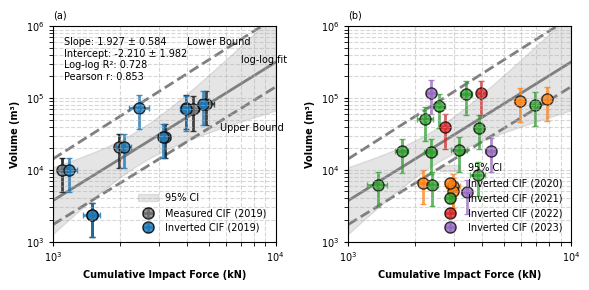

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5.5, 5.5))

# Set log-log scale
ax.set_xscale('log')
ax.set_yscale('log')

if interval_seconds == 5:
    xlim_l = 1e3
    xlim_u = 1e5
    xlim_major = 4_000
    xlim_minor = 500
elif interval_seconds == 15:
    xlim_l = 1e3
    xlim_u = 1e4
    xlim_major = 1_000
    xlim_minor = 250

# ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
# ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.tick_params(axis='both', which='major', labelsize=12, length=6)
ax.tick_params(axis='both', which='minor', labelsize=12, length=3)
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,)))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,)))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12))

ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=12, fontweight="bold")
ax.set_ylabel('Volume (m³)', fontsize=12, fontweight="bold")

# Plot target data
ax.errorbar(csum_list, volume_2019, yerr=volume_bounds_2019.T, xerr=csum_bounds.T,
            fmt='o',
            color='grey',
            label=f'Measured CIF (2019)',
            markersize=8,
            markeredgecolor="k",
            capsize=2,
            elinewidth=2,
            ecolor='k',
            zorder=0,
            alpha=0.8)

# Regression Line
csum_list_2, volume_2019_2 = [], []
for csum, vol, julday in zip(csum_list, volume_2019, julday_list_2019):
    if julday in ["161-19", "172-19", "196-19", "207-19", "223-19", "232-19"]: # Data with new volumes
        csum_list_2.append(csum)
        volume_2019_2.append(vol)
csum_list_2 = np.array(csum_list_2)
volume_2019_2 = np.array(volume_2019_2)
lower_csum_list = csum_list_2 - csum_list_2 * 0.5
upper_csum_list = csum_list_2 + csum_list_2 * 0.5

# LOWER REGRESSION LINE
x = lower_csum_list
y = volume_2019_2
xerr = csum_bounds[[0,1,3,4,5,6]].T
yerr = volume_bounds_2019[[0,1,3,4,5,6]].T
y_arr = np.array(y)
xerr_1d = np.mean(np.abs(xerr), axis=0)
yerr_1d = np.mean(np.abs(yerr), axis=0)
log_x = np.log10(x)
log_y = np.log10(y_arr)
# convert absolute errors to log-space uncertainties
sx = xerr_1d / (x * np.log(10))
sy = yerr_1d / (y_arr * np.log(10))

data = RealData(log_x, log_y, sx=sx, sy=sy)
model = Model(linear_function)
odr_inst = ODR(data, model, beta0=[0, 1])
output = odr_inst.run()

p_fit_l = output.beta
p_std_l = output.sd_beta

x_fit = np.logspace(np.log10(xlim_l), np.log10(xlim_u), 100)
log_x_fit = np.log10(x_fit)
log_y_fit = linear_function(p_fit_l, log_x_fit)
y_fit_l = 10**log_y_fit

t_val = 1.96
residuals = log_y - linear_function(p_fit_l, log_x)
residual_std = np.std(residuals, ddof=1)
mean_log_x = np.mean(log_x)
sxx = np.sum((log_x - mean_log_x) ** 2)
y_ci_log = t_val * residual_std * np.sqrt(1 / len(log_x) + (log_x_fit - mean_log_x) ** 2 / sxx)
y_lower = 10 ** (log_y_fit - y_ci_log)
y_upper = 10 ** (log_y_fit + y_ci_log)

# UPPER REGRESSION
x = upper_csum_list
y = volume_2019_2
xerr = csum_bounds[[0,1,3,4,5,6]].T
yerr = volume_bounds_2019[[0,1,3,4,5,6]].T
y_arr = np.array(y)
xerr_1d = np.mean(np.abs(xerr), axis=0)
yerr_1d = np.mean(np.abs(yerr), axis=0)
log_x = np.log10(x)
log_y = np.log10(y_arr)
# convert absolute errors to log-space uncertainties
sx = xerr_1d / (x * np.log(10))
sy = yerr_1d / (y_arr * np.log(10))

data = RealData(log_x, log_y, sx=sx, sy=sy)
model = Model(linear_function)
odr_inst = ODR(data, model, beta0=[0, 1])
output = odr_inst.run()

p_fit_u = output.beta
p_std_u = output.sd_beta

x_fit = np.logspace(np.log10(xlim_l), np.log10(xlim_u), 100)
log_x_fit = np.log10(x_fit)
log_y_fit = linear_function(p_fit_u, log_x_fit)
y_fit_u = 10**log_y_fit

t_val = 1.96
residuals = log_y - linear_function(p_fit_u, log_x)
residual_std = np.std(residuals, ddof=1)
mean_log_x = np.mean(log_x)
sxx = np.sum((log_x - mean_log_x) ** 2)
y_ci_log = t_val * residual_std * np.sqrt(1 / len(log_x) + (log_x_fit - mean_log_x) ** 2 / sxx)
y_lower = 10 ** (log_y_fit - y_ci_log)
y_upper = 10 ** (log_y_fit + y_ci_log)

# # convert absolute errors to log-space uncertainties
# sx = xerr_1d / (x * np.log(10))
# sy = yerr_1d / (y_arr * np.log(10))

# REGRESSION LINE
x = csum_list_2
y = volume_2019_2
xerr = csum_bounds[[0,1,3,4,5,6]].T
yerr = volume_bounds_2019[[0,1,3,4,5,6]].T
y_arr = np.array(y)
xerr_1d = np.mean(np.abs(xerr), axis=0)
yerr_1d = np.mean(np.abs(yerr), axis=0)
log_x = np.log10(x)
log_y = np.log10(y_arr)
# convert absolute errors to log-space uncertainties
sx = xerr_1d / (x * np.log(10))
sy = yerr_1d / (y_arr * np.log(10))

data = RealData(log_x, log_y, sx=sx, sy=sy)
model = Model(linear_function)
odr_inst = ODR(data, model, beta0=[0, 1])
output = odr_inst.run()

p_fit = output.beta
p_std = output.sd_beta

x_fit = np.logspace(np.log10(xlim_l), np.log10(xlim_u), 100)
log_x_fit = np.log10(x_fit)
log_y_fit = linear_function(p_fit, log_x_fit)
y_fit = 10**log_y_fit

t_val = 1.96
residuals = log_y - linear_function(p_fit, log_x)
residual_std = np.std(residuals, ddof=1)
mean_log_x = np.mean(log_x)
sxx = np.sum((log_x - mean_log_x) ** 2)
y_ci_log = t_val * residual_std * np.sqrt(1 / len(log_x) + (log_x_fit - mean_log_x) ** 2 / sxx)
y_lower = 10 ** (log_y_fit - y_ci_log)
y_upper = 10 ** (log_y_fit + y_ci_log)

# convert absolute errors to log-space uncertainties
# sx = xerr_1d / (x * np.log(10))
# sy = yerr_1d / (y_arr * np.log(10))

ax.plot(x_fit, y_fit_u, 'k--', linewidth=2, alpha=0.5, zorder=0)
ax.plot(x_fit, y_fit_l, 'k--', linewidth=2, alpha=0.5, zorder=0)
ax.plot(x_fit, y_fit, 'k-', linewidth=2, alpha=0.5, zorder=0)
ax.fill_between(x_fit, y_lower, y_upper, alpha=0.2, color='grey', label='95% CI', zorder=0)

r2_log = r2_score(log_y, linear_function(p_fit, log_x))
corr_log, _ = stats.pearsonr(log_x, log_y)

print("Fitted Parameters:")
print(f"Slope: {p_fit[1]:.6f} ± {p_std[1]:.6f}")
print(f"Intercept: {p_fit[0]:.6f} ± {p_std[0]:.6f}")
print(f"Log-log R2: {r2_log:.4f}, log Pearson corr: {corr_log:.4f}")


# xLSTM predictions
ax.errorbar(results_2019['xLSTM'][:, 0],
            volume_2019,
            yerr=volume_bounds_2019.T,
            xerr=results_2019['xLSTM'][:, 3:].T,
            fmt='o',
            color='C0',
            label=f'Inverted CIF (2019)',
            markersize=8,
            markeredgecolor="k",
            capsize=2,
            elinewidth=2,
            ecolor='C0',
            zorder=1,
            alpha=0.8)

info_text = (
    f"Slope: {p_fit[1]:.3f} ± {p_std[1]:.3f}\n"
    f"Intercept: {p_fit[0]:.3f} ± {p_std[0]:.3f}\n"
    f"Log-log R²: {r2_log:.3f}\n"
    f"Pearson r: {corr_log:.3f}"
)
ax.text(0.05, 0.95, info_text, transform=ax.transAxes, fontsize=7,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0))

ax.text(0.60, 0.95, "Lower Bound", transform=ax.transAxes, fontsize=7,
        verticalalignment='top')
ax.text(0.75, 0.55, "Upper Bound", transform=ax.transAxes, fontsize=7,
        verticalalignment='top')
ax.text(7_000, 400_000, "log-log fit", fontsize=7, verticalalignment='top')

ax.legend(loc="best", fontsize=7)

leg = ax.get_legend()
if leg:
    leg.get_frame().set_alpha(0)

ax.set_xlim(xlim_l, xlim_u)
ax.set_ylim(1e3, 1e6)
ax.set_title("(a)", loc="left", fontsize=7)


ax.grid(True, linestyle="--", alpha=0.5, which='both')
ax.tick_params(axis='both', which='major', labelsize=7, length=3)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)

fig.tight_layout()
# fig.savefig(f"./output_images11/log-log-vol-CIF-2019-{vol_err_percent}_{interval_seconds}.png", dpi=600, transparent=True)

In [61]:
# r2 = r2_score(log_csum, log_volume)
# corr, _ = stats.pearsonr(log_csum, log_volume)
# print(f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}")

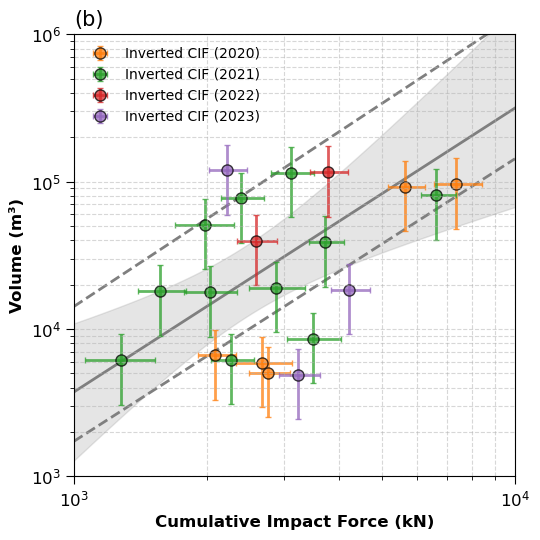

In [61]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5.5, 5.5))

# Set log-log scale
ax.set_xscale('log')
ax.set_yscale('log')

if interval_seconds == 5:
    xlim_l = 1e3
    xlim_u = 1e5
    xlim_major = 4_000
    xlim_minor = 500
elif interval_seconds == 15:
    xlim_l = 1e3
    xlim_u = 1e4
    xlim_major = 1_000
    xlim_minor = 250

# ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
# ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.tick_params(axis='both', which='major', labelsize=12, length=6)
ax.tick_params(axis='both', which='minor', labelsize=12, length=3)
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,)))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,)))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12))

ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=12, fontweight="bold")
ax.set_ylabel('Volume (m³)', fontsize=12, fontweight="bold")

ax.plot(x_fit, y_fit_u, 'k--', linewidth=2, alpha=0.5, zorder=0)
ax.plot(x_fit, y_fit_l, 'k--', linewidth=2, alpha=0.5, zorder=0)
ax.plot(x_fit, y_fit, 'k-', linewidth=2, alpha=0.5, zorder=0)
ax.fill_between(x_fit, y_lower, y_upper, alpha=0.2, color='grey', zorder=0)

# 2020
ax.errorbar(results_2020['xLSTM'][:, 0],
            volume_2020,
            yerr=volume_bounds_2020.T,
            xerr=results_2020['xLSTM'][:, 3:].T,
            fmt='o',
            color='C1',
            label="Inverted CIF (2020)",
            markersize=8,
            markeredgecolor="k",
            capsize=2,
            elinewidth=2,
            ecolor='C1',
            zorder=1,
            alpha=0.75)

# 2021
ax.errorbar(results_2021['xLSTM'][:, 0],
            volume_2021,
            yerr=volume_bounds_2021.T,
            xerr=results_2021['xLSTM'][:, 3:].T,
            fmt='o',
            color='C2',
            label="Inverted CIF (2021)",
            markersize=8,
            markeredgecolor="k",
            capsize=2,
            elinewidth=2,
            ecolor='C2',
            zorder=1,
            alpha=0.75)

# 2022
ax.errorbar(results_2022['xLSTM'][:, 0],
            volume_2022,
            yerr=volume_bounds_2022.T,
            xerr=results_2022['xLSTM'][:, 3:].T,
            fmt='o',
            color='C3',
            label="Inverted CIF (2022)",
            markersize=8,
            markeredgecolor="k",
            capsize=2,
            elinewidth=2,
            ecolor='C3',
            zorder=1,
            alpha=0.75)

# 2023
ax.errorbar(results_2023['xLSTM'][:, 0],
            volume_2023,
            yerr=volume_bounds_2023.T,
            xerr=results_2023['xLSTM'][:, 3:].T,
            fmt='o',
            color='C4',
            label="Inverted CIF (2023)",
            markersize=8,
            markeredgecolor="k",
            capsize=2,
            elinewidth=2,
            ecolor='C4',
            zorder=1,
            alpha=0.75)

ax.legend(loc="best", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5, which='both')

ax.set_xlim(xlim_l, xlim_u)
ax.set_ylim(1e3, 1e6)
ax.set_title("(b)", loc="left", fontsize=15)
fig.tight_layout()
leg = ax.get_legend()
if leg:
    leg.get_frame().set_alpha(0)
fig.savefig(f"./output_images11/log-log-vol-CIF-2020-2023-{vol_err_percent}_{interval_seconds}.png", dpi=600, transparent=True)

In [63]:
results_df = pd.DataFrame(columns=["Year", "Julian-Day", "Volume", "Estimated Volume Lower", "Estimated Volume", "Estimated Volume Upper", "CIF", "CIF_Lower", "CIF_Upper"])
year = 2019
for i, (julday, vol) in enumerate(zip(julday_list_2019, volume_2019)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper, _, _ = results_2019['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [161, 183]:
        vol_est = np.round(10**(p_fit_u[1] * np.log10(csum) + p_fit_u[0]))
        vol_est_lower = np.round(10**(p_fit_u[1] * np.log10(csum_lower) + p_fit_u[0]))
        vol_est_upper = np.round(10**(p_fit_u[1] * np.log10(csum_upper) + p_fit_u[0]))
    elif julday in []:
        vol_est = np.round(10**(p_fit_l[1] * np.log10(csum) + p_fit_l[0]))
        vol_est_lower = np.round(10**(p_fit_l[1] * np.log10(csum_lower) + p_fit_l[0]))
        vol_est_upper = np.round(10**(p_fit_l[1] * np.log10(csum_upper) + p_fit_l[0]))
    else:
        vol_est = np.round(10**(p_fit[1] * np.log10(csum) + p_fit[0]))
        vol_est_lower = np.round(10**(p_fit[1] * np.log10(csum_lower) + p_fit[0]))
        vol_est_upper = np.round(10**(p_fit[1] * np.log10(csum_upper) + p_fit[0]))
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum, csum_lower, csum_upper]

year = 2020
for i, (julday, vol) in enumerate(zip(julday_list_2020, volume_2020)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper, _, _ = results_2020['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [160, 169, 181]:
        vol_est = np.round(10**(p_fit_u[1] * np.log10(csum) + p_fit_u[0]))
        vol_est_lower = np.round(10**(p_fit_u[1] * np.log10(csum_lower) + p_fit_u[0]))
        vol_est_upper = np.round(10**(p_fit_u[1] * np.log10(csum_upper) + p_fit_u[0]))
    elif julday in []:
        vol_est = np.round(10**(p_fit_l[1] * np.log10(csum) + p_fit_l[0]))
        vol_est_lower = np.round(10**(p_fit_l[1] * np.log10(csum_lower) + p_fit_l[0]))
        vol_est_upper = np.round(10**(p_fit_l[1] * np.log10(csum_upper) + p_fit_l[0]))
    else:
        vol_est = np.round(10**(p_fit[1] * np.log10(csum) + p_fit[0]))
        vol_est_lower = np.round(10**(p_fit[1] * np.log10(csum_lower) + p_fit[0]))
        vol_est_upper = np.round(10**(p_fit[1] * np.log10(csum_upper) + p_fit[0]))
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum, csum_lower, csum_upper]

year = 2021
for i, (julday, vol) in enumerate(zip(julday_list_2021, volume_2021)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper, _, _ = results_2021['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [173, 197, 262]:
        vol_est = np.round(10**(p_fit_u[1] * np.log10(csum) + p_fit_u[0]))
        vol_est_lower = np.round(10**(p_fit_u[1] * np.log10(csum_lower) + p_fit_u[0]))
        vol_est_upper = np.round(10**(p_fit_u[1] * np.log10(csum_upper) + p_fit_u[0]))
    elif julday in [175, 187, 194]:
        vol_est = np.round(10**(p_fit_l[1] * np.log10(csum) + p_fit_l[0]))
        vol_est_lower = np.round(10**(p_fit_l[1] * np.log10(csum_lower) + p_fit_l[0]))
        vol_est_upper = np.round(10**(p_fit_l[1] * np.log10(csum_upper) + p_fit_l[0]))
    else:
        vol_est = np.round(10**(p_fit[1] * np.log10(csum) + p_fit[0]))
        vol_est_lower = np.round(10**(p_fit[1] * np.log10(csum_lower) + p_fit[0]))
        vol_est_upper = np.round(10**(p_fit[1] * np.log10(csum_upper) + p_fit[0]))
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum, csum_lower, csum_upper]

year = 2022
for i, (julday, vol) in enumerate(zip(julday_list_2022, volume_2022)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper, _, _ = results_2022['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in []:
        vol_est = np.round(10**(p_fit_u[1] * np.log10(csum) + p_fit_u[0]))
        vol_est_lower = np.round(10**(p_fit_u[1] * np.log10(csum_lower) + p_fit_u[0]))
        vol_est_upper = np.round(10**(p_fit_u[1] * np.log10(csum_upper) + p_fit_u[0]))
    elif julday in [185]:
        vol_est = np.round(10**(p_fit_l[1] * np.log10(csum) + p_fit_l[0]))
        vol_est_lower = np.round(10**(p_fit_l[1] * np.log10(csum_lower) + p_fit_l[0]))
        vol_est_upper = np.round(10**(p_fit_l[1] * np.log10(csum_upper) + p_fit_l[0]))
    else:
        vol_est = np.round(10**(p_fit[1] * np.log10(csum) + p_fit[0]))
        vol_est_lower = np.round(10**(p_fit[1] * np.log10(csum_lower) + p_fit[0]))
        vol_est_upper = np.round(10**(p_fit[1] * np.log10(csum_upper) + p_fit[0]))
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum, csum_lower, csum_upper]

year = 2023
for i, (julday, vol) in enumerate(zip(julday_list_2023, volume_2023)):
    julday = int(julday.split("-")[0])
    csum, csum_lower, csum_upper, _, _ = results_2023['xLSTM'][i,:]
    csum, csum_lower, csum_upper = np.round(csum), np.round(csum_lower), np.round(csum_upper)
    if julday in [153, 161]:
        vol_est = np.round(10**(p_fit_u[1] * np.log10(csum) + p_fit_u[0]))
        vol_est_lower = np.round(10**(p_fit_u[1] * np.log10(csum_lower) + p_fit_u[0]))
        vol_est_upper = np.round(10**(p_fit_u[1] * np.log10(csum_upper) + p_fit_u[0]))
    elif julday in [193]:
        vol_est = np.round(10**(p_fit_l[1] * np.log10(csum) + p_fit_l[0]))
        vol_est_lower = np.round(10**(p_fit_l[1] * np.log10(csum_lower) + p_fit_l[0]))
        vol_est_upper = np.round(10**(p_fit_l[1] * np.log10(csum_upper) + p_fit_l[0]))
    else:
        vol_est = np.round(10**(p_fit[1] * np.log10(csum) + p_fit[0]))
        vol_est_lower = np.round(10**(p_fit[1] * np.log10(csum_lower) + p_fit[0]))
        vol_est_upper = np.round(10**(p_fit[1] * np.log10(csum_upper) + p_fit[0]))
    results_df.loc[len(results_df)] = [year, julday, vol, vol_est_lower, vol_est, vol_est_upper, csum, csum_lower, csum_upper]


In [64]:
results_df["Uncertainty_Lower"] = np.round((results_df['Estimated Volume'] - results_df['Estimated Volume Lower']) * 100 / results_df['Estimated Volume'],2)
results_df["Uncertainty_Upper"] = np.round((results_df['Estimated Volume Upper'] - results_df['Estimated Volume']) * 100 / results_df['Estimated Volume'],2)
results_df["Estimated"] = ["Yes" if j < i < k else "No" for idx, (i,j,k) in results_df.loc[:, ['Volume', "Estimated Volume Lower", "Estimated Volume Upper"]].iterrows()]
results_df["Absolute_Error"] = [np.round((i - j)) for idx, (i,j) in results_df.loc[:, ['Volume', "Estimated Volume"]].iterrows()]
results_df['Percent_Error'] = np.round(np.abs(results_df['Absolute_Error'] / results_df['Volume']), 4) * 100

In [65]:
results_df.to_csv(f"./output_images11/vol_estimates_{interval}secs.csv")

In [66]:
results_df

,Year,Julian-Day,Volume,Estimated Volume Lower,Estimated Volume,Estimated Volume Upper,CIF,CIF_Lower,CIF_Upper,Uncertainty_Lower,Uncertainty_Upper,Estimated,Absolute_Error,Percent_Error
0,2019.0,161.0,2313.0,2759.0,3488.0,4532.0,1442.0,1276.0,1653.0,20.90,29.93,No,-1175.0,50.80
1,2019.0,172.0,83123.0,55730.0,67158.0,82520.0,4477.0,4064.0,4982.0,17.02,22.87,No,15965.0,19.21
2,2019.0,182.0,73144.0,14293.0,18870.0,25322.0,2317.0,2006.0,2699.0,24.26,34.19,No,54274.0,74.20
3,2019.0,196.0,9869.0,3963.0,4965.0,6204.0,1159.0,1031.0,1301.0,20.18,24.95,No,4904.0,49.69
4,2019.0,207.0,29077.0,25304.0,30194.0,36872.0,2957.0,2698.0,3280.0,16.20,22.12,Yes,-1117.0,3.84
5,2019.0,223.0,70705.0,30115.0,41076.0,59162.0,3469.0,2953.0,4192.0,26.68,44.03,No,29629.0,41.91
6,2019.0,232.0,21031.0,11426.0,14102.0,18139.0,1992.0,1786.0,2270.0,18.98,28.63,No,6929.0,32.95
7,2020.0,156.0,92424.0,87934.0,104593.0,127787.0,5634.0,5149.0,6251.0,15.93,22.18,Yes,-12169.0,13.17
8,2020.0,160.0,5872.0,8747.0,11417.0,15325.0,2676.0,2329.0,3120.0,23.39,34.23,No,-5545.0,94.43
9,2020.0,169.0,5053.0,9997.0,12089.0,15119.0,2757.0,2497.0,3098.0,17.30,25.06,No,-7036.0,139.24


In [67]:
len(results_df[results_df['Absolute_Error']>0])

11

In [68]:
results_df[results_df["Volume"]>10_000]['Percent_Error'].agg(['mean', 'std'])

mean    34.227368
std     23.749521
Name: Percent_Error, dtype: float64

In [69]:
from collections import Counter
Counter(results_df['Estimated'])

Counter({'No': 20, 'Yes': 8})

In [70]:
len(results_df[results_df['Percent_Error'] < 30]) / 28

0.39285714285714285

In [71]:
temp = results_df[results_df['Volume'] > 10000]
print(len(temp[temp['Percent_Error'] < 30]))
print(Counter(temp['Estimated']))

9
Counter({'No': 13, 'Yes': 6})


# Looking into seismic signatures

In [72]:
year = 2019
juldays_2019 = [161, 172, 182, 183, 196, 207, 223, 232]
event_ids_2019 = ["1", "3", "4", "5", "6", "7", "8", "9"]

year = 2020
juldays_2020 = [156, 160, 169, 181, 243] # 159
start_times_2020 = ["2020-06-04 15:30:00", "2020-06-08 17:30:00", "2020-06-17 04:30:00", "2020-06-29 05:00:00", "2020-08-30 05:45:00"] # "2020-06-07 09:00:00"
end_times_2020 = ["2020-06-04 18:00:00", "2020-06-08 21:00:00", "2020-06-17 07:00:00", "2020-06-29 07:30:00", "2020-08-30 12:00:00"] # "2020-06-07 10:30:00"

year = 2021
juldays_2021 = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times_2021 = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:00:00", "2021-06-05 09:00:00",
            "2021-06-22 19:00:00", "2021-06-24 15:00:00", "2021-07-06 18:30:00", "2021-07-13 15:00:00",
            "2021-07-16 03:30:00", "2021-08-07 13:30:00", "2021-09-19 05:30:00"]
end_times_2021 = ["2021-05-11 19:30:00", "2021-05-16 22:00:00", "2021-05-22 02:30:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 19:00:00", "2021-07-06 22:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 18:00:00", "2021-09-19 12:30:00"]

year = 2022
juldays_2022 = [156, 185]
start_times_2022 = ["2022-06-05 11:15:00", "2022-07-04 21:40:00"]
end_times_2022 = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]

year = 2023
juldays_2023 = [153, 161, 193]
start_times_2023 = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:30:00"]
end_times_2023 = ["2023-06-02 21:30:00", "2023-06-10 09:30:00", "2023-07-12 06:00:00"]